Let's revisit the Palmer penguins dataset and apply some basic linear reagression. Our task is to evaluate the goodness of the model, we'll discuss the theory of linear regression next week. For now, it suffices to think of this as "fitting a line among a set of points".

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv('penguins_size.csv').dropna()
df_train, df_test = train_test_split(df,random_state=1234)

In [4]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
independent_variables = ['culmen_length_mm','culmen_depth_mm','flipper_length_mm']
dependent_variable = 'body_mass_g'
X_train = df_train[independent_variables]
X_test = df_test[independent_variables]
y_train = df_train[dependent_variable]
y_test = df_test[dependent_variable]
lr.fit(X_train,y_train)

LinearRegression()

In [5]:
y_predicted = lr.predict(X_test)

The model aims to predict the body mass of a penguin by using a linear combination of the other numerical features (culmen length/depth and flipper length).

Let's start by plotting the absolute and relative error. Note that we are using a signed version of the error: we should expect the error to be strongly concentrated around 0 if the model makes sense and somewhat symmetrically around the mean.

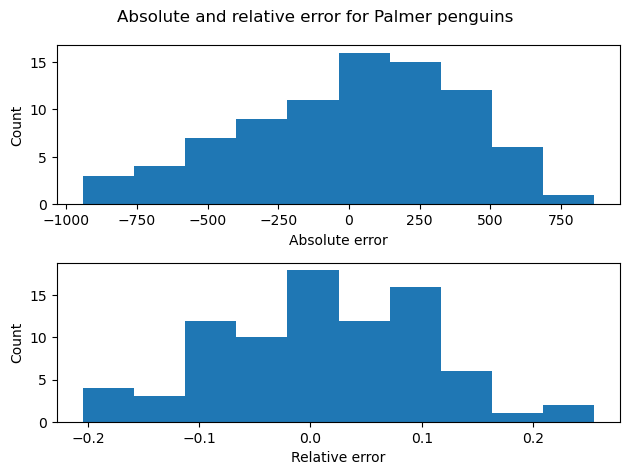

In [6]:
import matplotlib.pyplot as plt
import numpy as np
fig, axs = plt.subplots(2) 
axs[0].hist(y_predicted-y_test,bins=10)
axs[1].hist((y_predicted-y_test)/y_test,bins=10)
axs[0].set_xlabel('Absolute error')
axs[0].set_ylabel('Count')
axs[1].set_xlabel('Relative error')
axs[1].set_ylabel('Count')
fig.suptitle('Absolute and relative error for Palmer penguins')
fig.tight_layout()

This looks like a kind of bell curve. It's difficult to determine if the error is truly skewed because the number of samples is kind of small. Let's compute some statistics, such as Mean Squared Error (MSE) and Root Mean Squared (RMS).

In [7]:
mse = np.mean((y_test-y_predicted)**2)
mse

147847.6686572796

In [8]:
rms = np.sqrt(mse)
rms

384.50964702758705

So this gives us the interpretation that the typical prediction is off by about 384 grams, or this is the order of magnitude of the error (let's say around 400 grams to be the typical precision).

Let's see if we can do better by focusing on a smaller subset; we now have three different species of penguins and two genders, both of which factor heavily into, well, how heavy the penguins are.

In [9]:
df_adelie_male = df.query('species == "Adelie" and sex == "MALE"')
df_adelie_male_train, df_adelie_male_test = train_test_split(df_adelie_male)
X_adelie_male_train = df_adelie_male_train[independent_variables]
X_adelie_male_test = df_adelie_male_test[independent_variables]
y_adelie_male_train = df_adelie_male_train[dependent_variable]
y_adelie_male_test = df_adelie_male_test[dependent_variable]
lr_adelie_male = LinearRegression()
lr_adelie_male.fit(X_adelie_male_train,y_adelie_male_train)
y_adelie_male_pred = lr_adelie_male.predict(X_adelie_male_test)
fig.savefig('palmer_penguins_error.pdf')

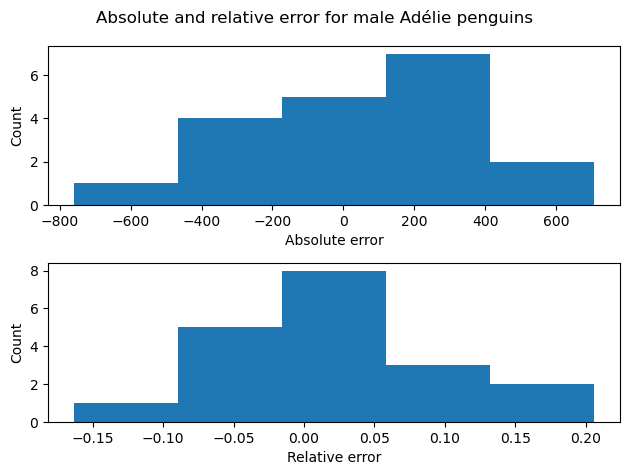

In [42]:
fig, axs = plt.subplots(2) 
axs[0].hist(y_adelie_male_pred-y_adelie_male_test,bins=5)
axs[1].hist((y_adelie_male_pred-y_adelie_male_test)/y_adelie_male_test,bins=5)
axs[0].set_xlabel('Absolute error')
axs[0].set_ylabel('Count')
axs[1].set_xlabel('Relative error')
axs[1].set_ylabel('Count')
fig.suptitle('Absolute and relative error for male Adélie penguins')
fig.tight_layout()

In [48]:
mse_adelie_male = np.mean((y_adelie_male_pred-y_adelie_male_test)**2)
mse_adelie_male

92272.91336849621

In [49]:
rms_adelie_male = np.sqrt(mse_adelie_male)
rms_adelie_male

303.76456898146665

In [12]:
df.groupby('species')['body_mass_g'].mean()

species
Adelie       3706.164384
Chinstrap    3733.088235
Gentoo       5090.625000
Name: body_mass_g, dtype: float64

In [13]:
df.query('species == "Gentoo"').groupby('sex')['body_mass_g'].mean()

sex
.         4875.000000
FEMALE    4679.741379
MALE      5484.836066
Name: body_mass_g, dtype: float64